In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

### Motivation

In [3]:
alphabet = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ,.! " 
target = "Bacon and Ham!" 

In [4]:
class Individual:
    def __init__(self, string, fitness=0):
        self.string = string
        self.fitness = fitness


def similar(a, b):
    return SequenceMatcher(None, a, b)

def spawn_population(length=26, size=100):
    pop = []
    for i in range(size):
        string  = ''.join(random.choices(alphabet, k=length))
        individual = Individual(string)
        pop.append(individual)
    return pop

In [5]:
def mate(p1_, p2_): #A
    p1 = p1_.string
    p2 = p2_.string
    child1 = []
    child2 = []
    cross_pt = random.randint(0,len(p1))
    child1.extend(p1[0:cross_pt])
    child1.extend(p2[cross_pt:])
    child2.extend(p2[0:cross_pt])
    child2.extend(p1[cross_pt:])
    c1 = Individual(''.join(child1))
    c2 = Individual(''.join(child2))
    return c1, c2


def mutate(x, mut_rate=0.01): #B
    new_x_ = []
    for char in x.string:
        if random.random() < mut_rate:
            new_x_.extend(random.choices(alphabet,k=1))
        else:
            new_x_.append(char)
    new_x = Individual(''.join(new_x_))
    return new_x


In [9]:
def update_fitness(pop, target):
    for i in range(len(pop)):
        fit = similar(pop[i].string, target)
        pop[i].fitness = fit.ratio()

def mean_fitness(pop):
    avg_fit = 0
    for i in range(len(pop)):
        avg_fit += pop[i].fitness
    avg_fit /= len(pop)
    return avg_fit

def next_generation(pop, size=100, length=26, mut_rate=0.01): #B
    new_pop = []
    while len(new_pop) < size:
        parents = random.choices(pop,k=2, weights=[x.fitness for x in pop])
        offspring_ = mate(parents[0],parents[1])
        child1 = mutate(offspring_[0], mut_rate=mut_rate)
        child2 = mutate(offspring_[1], mut_rate=mut_rate)
        offspring = [child1, child2]
        new_pop.extend(offspring)
    return new_pop


In [22]:
num_generations = 1000
population_size = 900
str_len = len(target)
mutation_rate = 0.00001
display_rate = 100

pop_fit = []
pop = spawn_population(size=population_size, length=str_len)
done = False
for gen in range(num_generations):
    if gen % display_rate == 0:
        print(f'On generation: {gen}')
    update_fitness(pop, target)
    avg_fit = mean_fitness(pop)
    pop_fit.append(avg_fit) 
    new_pop = next_generation(pop, \
        size=population_size, length=str_len, mut_rate=mutation_rate)
    pop = new_pop
    for x in pop: 
        if x.string == target: 
            print("Target Found!")
            done = True
    if done:
        break

On generation: 0
On generation: 100
On generation: 200
On generation: 300
On generation: 400
On generation: 500
On generation: 600
On generation: 700
On generation: 800
On generation: 900


In [23]:
pop.sort(key=lambda x: x.fitness, reverse=True) 
pop[0].string

'Baconand .Ham!'

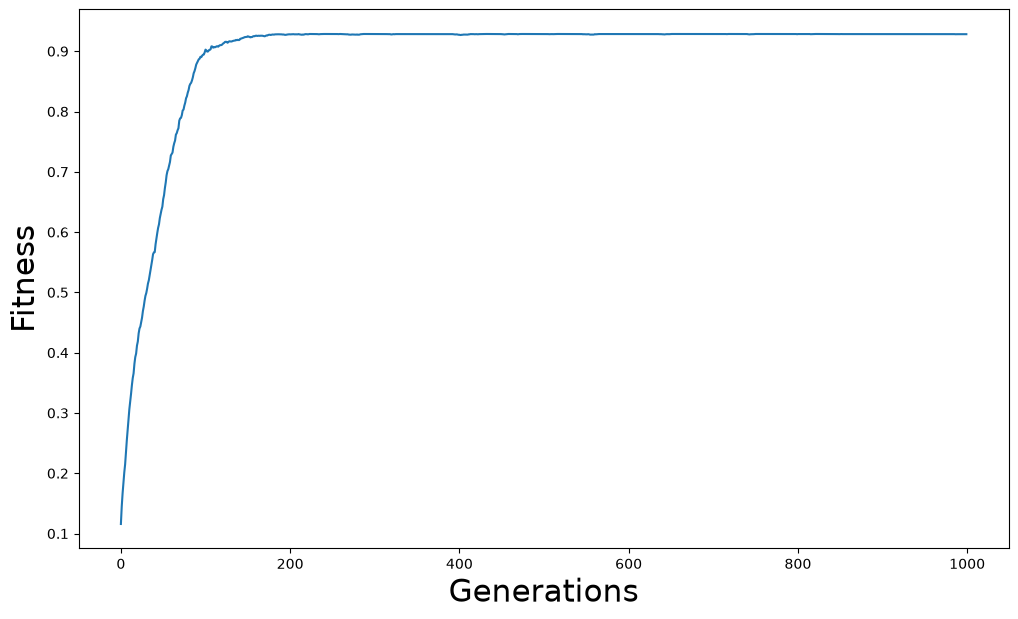

In [24]:
plt.figure(figsize=(12,7))
plt.xlabel("Generations",fontsize=22)
plt.ylabel("Fitness",fontsize=22)
plt.plot(pop_fit)